In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import json

In [2]:
curr_dir=os.getcwd()
grandparent_dir = os.path.abspath(os.path.join(curr_dir, os.pardir,os.pardir))
pardir=os.path.abspath(os.path.join(curr_dir, os.pardir))
print(pardir)
sys.path.append(os.path.join(pardir))
print(sys.path)

c:\Users\Pc\Documents\Tese\LAVA_SNN_ripples\seizure_detection
['c:\\nrn\\lib\\python', 'c:\\Users\\Pc\\anaconda3\\envs\\lava_snn_ripples\\python39.zip', 'c:\\Users\\Pc\\anaconda3\\envs\\lava_snn_ripples\\DLLs', 'c:\\Users\\Pc\\anaconda3\\envs\\lava_snn_ripples\\lib', 'c:\\Users\\Pc\\anaconda3\\envs\\lava_snn_ripples', '', 'c:\\Users\\Pc\\anaconda3\\envs\\lava_snn_ripples\\lib\\site-packages', 'c:\\Users\\Pc\\anaconda3\\envs\\lava_snn_ripples\\lib\\site-packages\\win32', 'c:\\Users\\Pc\\anaconda3\\envs\\lava_snn_ripples\\lib\\site-packages\\win32\\lib', 'c:\\Users\\Pc\\anaconda3\\envs\\lava_snn_ripples\\lib\\site-packages\\Pythonwin', 'c:\\Users\\Pc\\Documents\\Tese\\LAVA_SNN_ripples\\seizure_detection']


In [8]:
bandpass=[1,70]
downsampled_fs = 1000 # Downsampled frequency
fraction=(0,0.8)
min_spikes=3
min_threshold=1.2

In [9]:
WINDOW_SIZE = int(200)   # in timesteps (ms) - The size of the window to slice the input data

# unit: timesteps (ms) - The number of steps that 2 consecutive windows must overlap to not lose any relevant CBs

# std, mean = ripples_std(parent) # 61 ms # in seconds
# INTERSECT_WINDOW_LEN=int((std+mean)*1000) # in timesteps (ms) - The size of the intersection window to slice the input data
INTERSECT_WINDOW_LEN=100 # in timesteps (ms) - The size of the intersection window to slice the input data

# unit: timesteps (ms) - The number of steps that the window must shift to get the next window
WINDOW_SHIFT = int(WINDOW_SIZE - INTERSECT_WINDOW_LEN)

MARGINS=(20,20)

## Extract Windows
Extract UP/DN spike Windows


In [10]:
load=False
data_dir=os.path.join(curr_dir,"up_dn_data")
# Only run this block if first time
from make_up_dn_iis import *
if 'windowed_input_data' not in locals():
    if load:
        windowed_path=os.path.join(curr_dir,"windowed_data")
        windowed_input_data = np.load(os.path.join(windowed_path,"windowed_input_data.npy"))
        windowed_gt = np.load(os.path.join(windowed_path,"windowed_gt.npy"))
        filtered_windows=np.load(os.path.join(windowed_path,"filtered_windows.npy"))
    else:
        windowed_input_data, windowed_gt, filtered_windows, ripple_ids=make_windows([0,1], WINDOW_SIZE,WINDOW_SHIFT,MARGINS,min_spikes=1,fraction=(0,1),min_threshold=min_threshold)
    print("windowed_input_data already loaded")

In [11]:
up_spikes_per_window = np.sum(windowed_input_data[:, :, 0], axis=1)    # Sum along time axis
down_spikes_per_window = np.sum(windowed_input_data[:, :, 1], axis=1)  # Sum along time axis
print("Up Spikes Total:",np.sum(up_spikes_per_window))
print("Down Spikes Total:",np.sum(down_spikes_per_window))
# print(config)

Up Spikes Total: 334680.0
Down Spikes Total: 324945.0


In [12]:
# See GT Class Distribution
# Set print options to see more elements
np.set_printoptions(linewidth=100, threshold=50, edgeitems=20)
print(f"Ground Truth Class Distribution: {np.unique(windowed_gt, return_counts=True)}")
GT_HFO_MASK = windowed_gt >= 0
# print(windowed_gt[0:1000])
# Define the number of windows with an HFO
num_hfo_windows = np.sum(GT_HFO_MASK)
print(f"Number of windows with an HFO: {num_hfo_windows}")
print(f"Percentage of windows with an HFO: {num_hfo_windows / windowed_gt.shape[0] * 100:.2f}%")

# Save to config.json
# config["num_hfo_windows"] = num_hfo_windows
# config["num_windows"] = windowed_gt.shape[0]
# config["percentage_hfo_windows"] = num_hfo_windows / windowed_gt.shape[0] * 100


Ground Truth Class Distribution: (array([ -1.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38., ..., 160., 161., 162., 163., 164., 165., 166., 167., 168.,
       169., 170., 171., 172., 173., 174., 175., 176., 177., 178., 179.], dtype=float32), array([175251,    246,    193,    275,    258,    201,    179,    273,    194,    163,    187,
          203,    217,    252,    249,    209,    199,    257,    164,     76, ...,     57,     49,
           51,     69,    111,    111,     69,     77,    117,     34,     65,     79,     48,
           67,     93,     30,     99,     75,     89,     76], dtype=int64))
Number of windows with an HFO: 18488
Percentage of windows with an HFO: 9.54%


In [13]:
# Find the indices to sort the input data by the nº of UP/DN spikes (descending order)
sorted_indices = np.argsort(
    -(np.sum(windowed_input_data[:, :, 0], axis=1) + np.sum(windowed_input_data[:, :, 1], axis=1)), 
)
sorted_spikes = windowed_input_data[sorted_indices]
sorted_gt= windowed_gt[sorted_indices]
sorted_filtered_windows=filtered_windows[sorted_indices]
sorted_ripples=ripple_ids[sorted_indices]
sorted_up_spikes_per_window = np.sum(sorted_spikes[:, :, 0], axis=1)    # Sum along time axis
sorted_down_spikes_per_window = np.sum(sorted_spikes[:, :, 1], axis=1)  # Sum along time axis
print(f"sorted_indices: {sorted_indices}")
print(f"Sorted_data: {sorted_spikes.shape} | Sorted_gt: {sorted_gt.shape}| Sorted_filtered_windows: {sorted_filtered_windows.shape}")
print(f"Sorted_gt preview: {sorted_gt[:10]}")
print(f"GT first window: {sorted_gt[0]} | GT last window: {sorted_gt[-1]}")
total_spikes_per_window = sorted_up_spikes_per_window + sorted_down_spikes_per_window
print(f"Total Spikes per window: {total_spikes_per_window[:10]} | {total_spikes_per_window[-10:]}")

sorted_indices: [103558 103523 135398 103530 103365 135406 127341 187904 188530 100245 103525 103414 127293 135451
 188593 127344 103526 100107 103561 100051 ... 115585 115586 115587 115590 115601 115602 115618
 115619 115621 115630 115632 115637 115639 115644 115646 115651 115653 115669 115693 193738]
Sorted_data: (193739, 200, 2) | Sorted_gt: (193739,)| Sorted_filtered_windows: (193739, 200)
Sorted_gt preview: [31. 43. 27. 49. 57. 21. 28. 23. 27. 31.]
GT first window: 31.0 | GT last window: -1.0
Total Spikes per window: [46. 45. 44. 43. 43. 42. 42. 41. 41. 41.] | [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [14]:
indices=np.arange(0,1000)
sorted_gt_distribution=sorted_gt[indices]
print(f"Sorted GT Distribution: {np.unique(sorted_gt_distribution, return_counts=True)}")
print(f"Total Spikes per window: {total_spikes_per_window[indices]}")


Sorted GT Distribution: (array([ -1.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38., ..., 103., 104., 105., 106., 107., 108., 109., 110., 111.,
       113., 120., 123., 125., 129., 132., 135., 147., 149., 175., 178.], dtype=float32), array([45, 23, 28, 23, 23, 18, 20, 32, 35, 14, 26, 43, 17, 21, 29, 18, 26, 31, 23,  5, ...,  7,  3,
        3,  5,  7,  1,  2,  2,  1,  1,  1,  2,  1,  8,  1,  2,  1,  1,  1,  1], dtype=int64))
Total Spikes per window: [46. 45. 44. 43. 43. 42. 42. 41. 41. 41. 41. 41. 41. 40. 40. 40. 39. 39. 39. 39. ... 25. 25. 25.
 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25.]


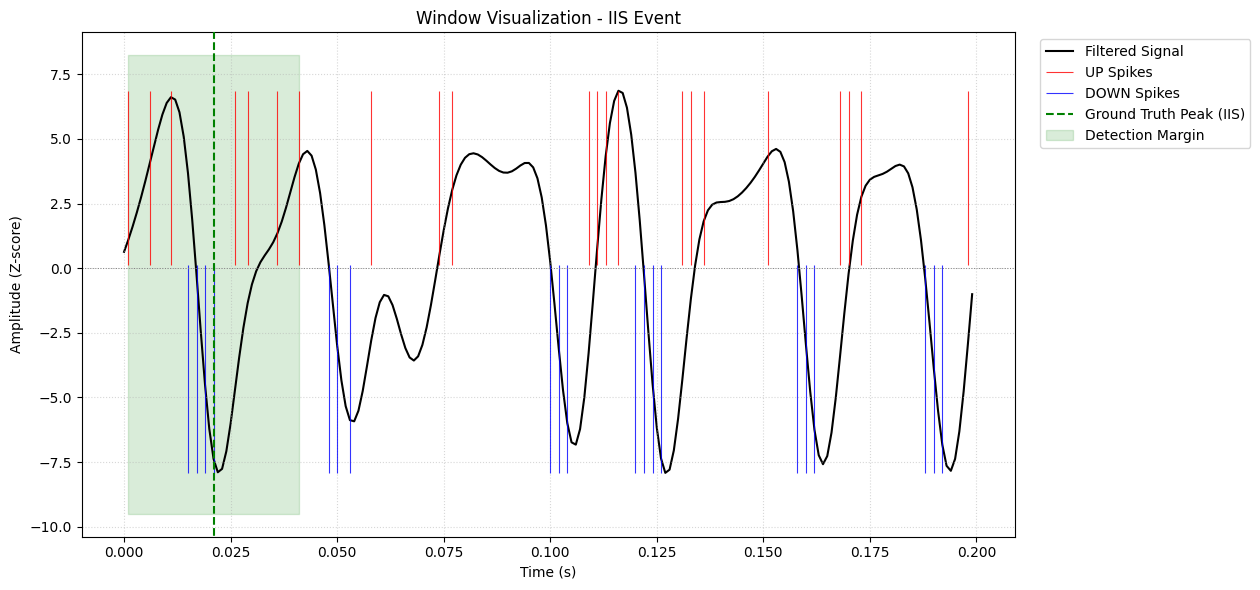

In [15]:
window=5
plot_spikes=sorted_spikes[window,:,:]
plot_gt=sorted_gt[window]
plot_filtered_window=sorted_filtered_windows[window,:]
iis_window_plot(plot_filtered_window, plot_spikes, plot_gt, downsampled_fs=downsampled_fs, detection_margins=MARGINS)# up_spikes_window = np.sum(plot_spikes[:, 0])    # Sum along time axis

In [16]:
is_hfo = windowed_gt >= 0
hfo_windows = windowed_input_data[is_hfo]       # shape: (N_HFO, 180, 2)
non_hfo_windows = windowed_input_data[~is_hfo]  # shape: (N_nonHFO, 180, 2)
windowed_gt_hfo = windowed_gt[is_hfo]       # shape: (N_HFO, 180, 2)
windowed_gt_non_hfo = windowed_gt[~is_hfo]  # shape: (N_nonHFO, 180, 2) 

In [17]:
# Sum over time axis
hfo_up_counts = np.sum(hfo_windows[:, :, 0], axis=1)
hfo_down_counts = np.sum(hfo_windows[:, :, 1], axis=1)
og_total_hfo_counts= hfo_up_counts + hfo_down_counts
nonhfo_up_counts = np.sum(non_hfo_windows[:, :, 0], axis=1)
nonhfo_down_counts= np.sum(non_hfo_windows[:, :,1], axis=1)
og_total_nonhfo_counts = nonhfo_up_counts + nonhfo_down_counts
average_total_counts= (np.sum(og_total_hfo_counts)+np.sum(og_total_nonhfo_counts))/len(windowed_input_data)

# Print the average counts
average_hfo_up_counts = np.mean(hfo_up_counts)
average_hfo_down_counts = np.mean(hfo_down_counts)
average_total_hfo_counts = np.mean(og_total_hfo_counts)
average_nonhfo_up_counts = np.mean(nonhfo_up_counts)
average_nonhfo_down_counts = np.mean(nonhfo_down_counts)
average_total_nonhfo_counts = np.mean(og_total_nonhfo_counts)
median_hfo_counts=np.median(og_total_hfo_counts)
median_nonhfo_counts=np.median(og_total_nonhfo_counts)
print(f"Average HFO Up Counts: {average_hfo_up_counts}")
print(f"Average HFO Down Counts: {average_hfo_down_counts}")
print(f"Average Total HFO Counts: {average_total_hfo_counts}")
print(f"Average Non-HFO Up Counts: {average_nonhfo_up_counts}")
print(f"Average Non-HFO Down Counts: {average_nonhfo_down_counts}")
print(f"Average Total Non-HFO Counts: {average_total_nonhfo_counts}")
print(f"Average Total Counts: {average_total_counts}")
print(f"Median HFO Counts: {median_hfo_counts}")
print(f"Median Non-HFO Counts: {median_nonhfo_counts}")

# # Add to config dictionary
# config.update({
#     "average_hfo_up_counts": average_hfo_up_counts,
#     "average_hfo_down_counts": average_hfo_down_counts,
#     "average_total_hfo_counts": average_total_hfo_counts,
#     "average_nonhfo_up_counts": average_nonhfo_up_counts,
#     "average_nonhfo_down_counts": average_nonhfo_down_counts,
#     "average_total_nonhfo_counts": average_total_nonhfo_counts,
#     "average_total_counts": average_total_counts,
#     "median_hfo_counts": median_hfo_counts,
#     "median_nonhfo_counts": median_nonhfo_counts,
# })


Average HFO Up Counts: 6.1132626568585025
Average HFO Down Counts: 5.785536564257897
Average Total HFO Counts: 11.8987992211164
Average Non-HFO Up Counts: 1.2648030539055413
Average Non-HFO Down Counts: 1.2438274246651946
Average Total Non-HFO Counts: 2.5086304785707356
Average Total Counts: 3.404709428664337
Median HFO Counts: 11.0
Median Non-HFO Counts: 2.0


In [22]:
def get_isi(spike_train):
    times_up = np.where(spike_train[:,0])[0]  # spike times (e.g., indices)
    times_down = np.where(spike_train[:,0])[0]  # spike times (e.g., indices)
    times_total= np.concatenate((times_up, times_down))
    times_total.sort()  # sort the spike times
    if len(times_total) < 2:
        return np.array([])  # no ISI to compute
    return np.diff(times_total)

# Example for all HFO windows (up channel):
hfo_up_isis = [get_isi(window[:, :]) for window in hfo_windows]
nonhfo_up_isis = [get_isi(window[:, :]) for window in non_hfo_windows]

hfo_up_isi_mean = np.array([np.mean(isi) if len(isi) > 0 else 0 for isi in hfo_up_isis])
nonhfo_up_isi_mean = np.array([np.mean(isi) if len(isi) > 0 else 0 for isi in nonhfo_up_isis])


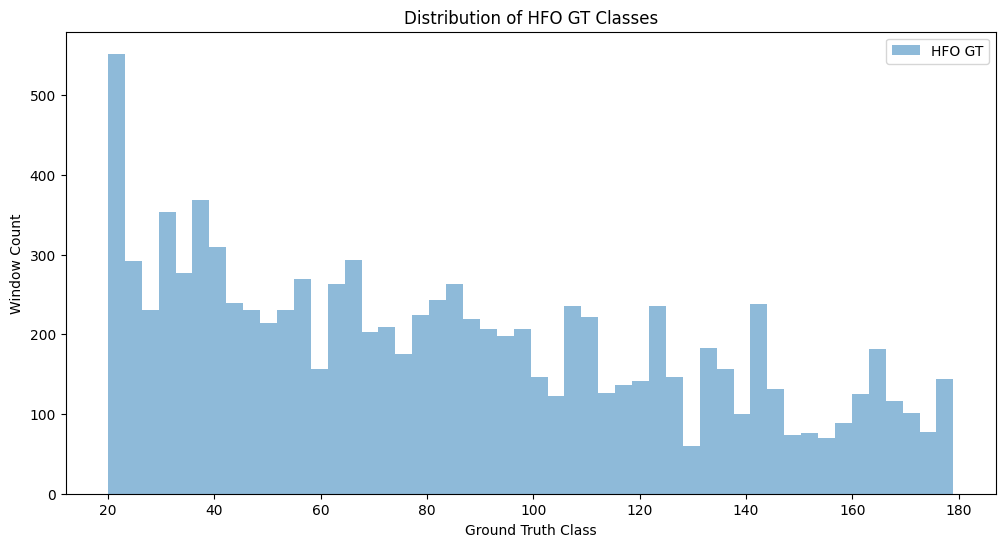

In [23]:
plt.subplots(figsize=(12, 6))
plt.hist(windowed_gt_hfo, bins=50, alpha=0.5, label='HFO GT')
plt.legend()
plt.title('Distribution of HFO GT Classes')
plt.xlabel('Ground Truth Class')
plt.ylabel('Window Count')
plt.show()

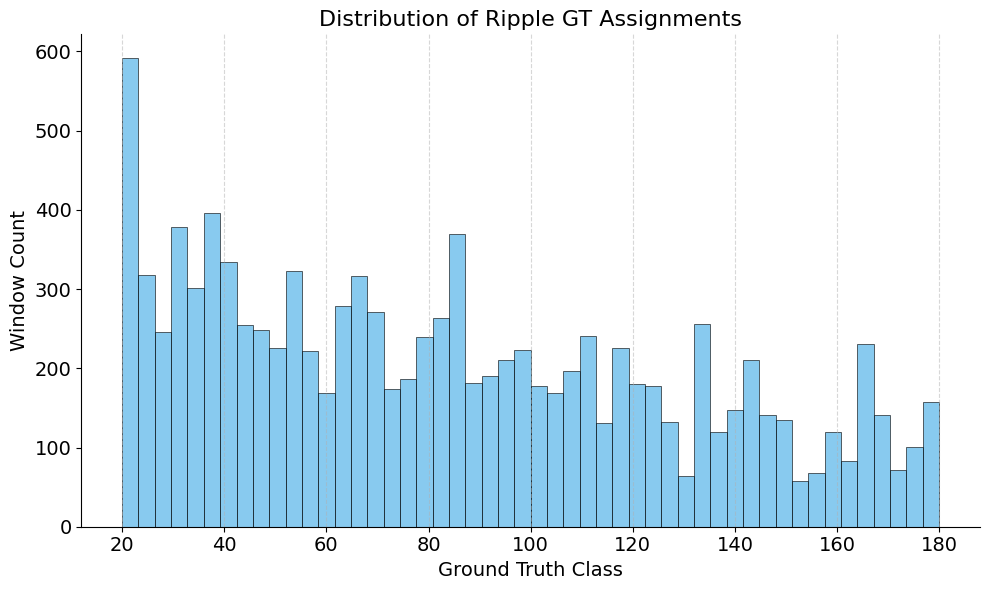

In [16]:
def plot_hfo_gt_distribution(windowed_gt_hfo):
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.hist(windowed_gt_hfo, bins=50, orientation='vertical', alpha=0.7, 
            color="#56B4E9", edgecolor='black', linewidth=0.6)

    # Labels and title
    ax.set_ylabel("Window Count", fontsize=14)
    ax.set_xlabel("Ground Truth Class", fontsize=14)
    ax.set_title("Distribution of Ripple GT Assignments", fontsize=16)

    # Style
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.tick_params(axis='both', labelsize=14)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    return fig, ax
fig, ax = plot_hfo_gt_distribution(windowed_gt_hfo)
path_figs=os.path.join(curr_dir,"dataset_up_down","figures")
file= os.path.join(path_figs,"hfo_gt_distribution.png")
# fig.savefig(file, dpi=300)

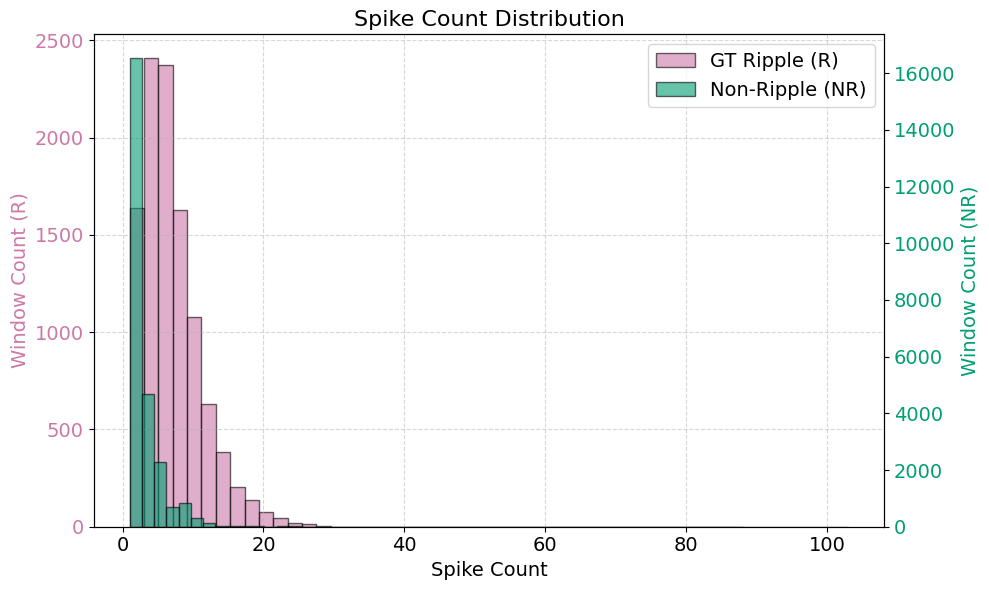

In [17]:
import matplotlib.pyplot as plt

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(10, 6 ))

# Plot first histogram (HFO)
color1 = "#CC79A7"  # Orange
counts1, bins1, patches1 = ax1.hist(og_total_hfo_counts, bins=50, alpha=0.6,
                                    label="HFO Up Spikes", color=color1, edgecolor='black')
ax1.set_xlabel("Spike Count", fontsize=14)
ax1.set_ylabel("Window Count (R)", fontsize=14, color=color1)
ax1.tick_params(axis='y', labelcolor=color1,labelsize=14)

# Create second y-axis
ax2 = ax1.twinx()
color2 = "#009E73"  # Blue
counts2, bins2, patches2 = ax2.hist(og_total_nonhfo_counts, bins=50, alpha=0.6,
                                    label="Non-HFO Up Spikes", color=color2, edgecolor='black')
ax2.set_ylabel("Window Count (NR)", fontsize=14, color=color2)
ax2.tick_params(axis='y', labelcolor=color2, labelsize=14)
ax1.tick_params(axis='x', labelsize=14) 
# Title and aesthetics
plt.title("Spike Count Distribution", fontsize=16)
fig.tight_layout()

# Legends (merged manually since twin axes can't auto-combine legends)
lines = [patches1[0], patches2[0]]
labels = ["GT Ripple (R)", "Non-Ripple (NR)"]
ax1.legend(lines, labels, loc="upper right", fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.5)
plt.show()

file= os.path.join(path_figs,"spike_count_distribution.png")
# fig.savefig(file, dpi=300)

In [18]:
hist_ripples = np.histogram(og_total_hfo_counts, bins=100)
hist_nonripples = np.histogram(og_total_nonhfo_counts, bins=100)

config={}
config["n_bins"]= len(hist_ripples[0])
config=evaluate_histogram(hist_ripples,hist_nonripples,config)


Bhattacharyya Distance: 0.9076
KL Divergence: 13.5057
Earth Mover’s Distance: 20.0291
Chi-Square Statistic: 373050938804.0442, p-value: 0.0000


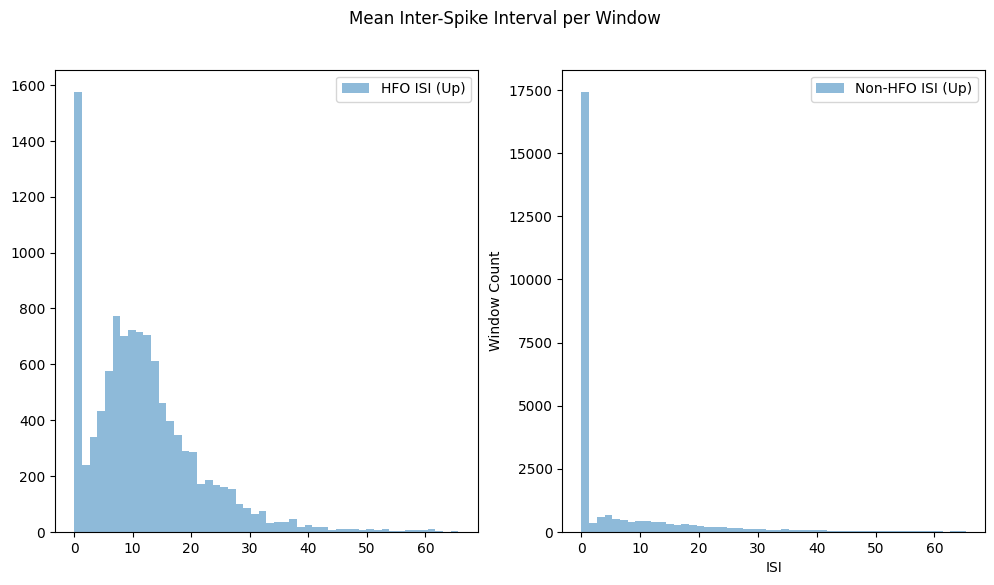

In [18]:
plt.subplots(1,2, figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(hfo_up_isi_mean, bins=50, alpha=0.5, label='HFO ISI (Up)')
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(nonhfo_up_isi_mean, bins=50, alpha=0.5, label='Non-HFO ISI (Up)')
plt.legend()
plt.suptitle('Mean Inter-Spike Interval per Window')
plt.xlabel('ISI')
plt.ylabel('Window Count')
plt.show()

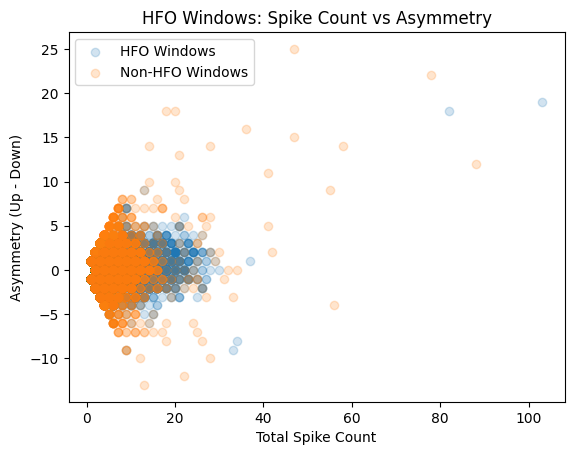

In [19]:
# Evaluate HFO windows
asymmetry_hfos = (hfo_up_counts - hfo_down_counts)
asymmetry_nonhfos = nonhfo_up_counts - nonhfo_down_counts

plt.scatter(og_total_hfo_counts,asymmetry_hfos , alpha=0.2, label='HFO Windows')
plt.scatter(og_total_nonhfo_counts,asymmetry_nonhfos, alpha=0.2, label='Non-HFO Windows')
plt.xlabel('Total Spike Count')
plt.ylabel('Asymmetry (Up - Down)')
plt.title('HFO Windows: Spike Count vs Asymmetry')
plt.legend()
plt.show()

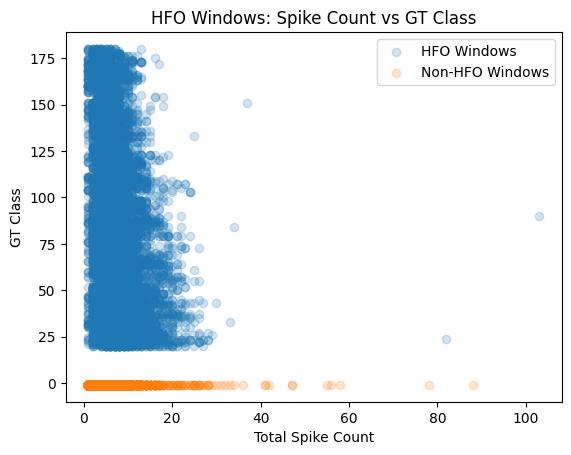

In [20]:
plt.scatter(og_total_hfo_counts,windowed_gt_hfo, alpha=0.2, label='HFO Windows')
plt.scatter(og_total_nonhfo_counts,windowed_gt_non_hfo, alpha=0.2, label='Non-HFO Windows')
plt.xlabel('Total Spike Count')
plt.ylabel('GT Class')
plt.title('HFO Windows: Spike Count vs GT Class')
plt.legend()
plt.show()
# print(config)

## Process Windows

In [21]:
p1_windowed_input_data,p1_windowed_gt,p1_ripple_ids=only_some_channels_per_ripple(windowed_input_data,windowed_gt,ripple_ids,3)


In [22]:
# See GT Class Distribution
# Set print options to see more elements
np.set_printoptions(linewidth=100, threshold=50, edgeitems=20)
print(f"Ground Truth Class Distribution: {np.unique(p1_windowed_gt, return_counts=True)}")



GT_HFO_MASK = p1_windowed_gt >= 0
# print(windowed_gt[0:1000])
# Define the number of windows with an HFO
num_hfo_windows = np.sum(GT_HFO_MASK)
print(f"Number of windows with an HFO: {num_hfo_windows}")
print(f"Percentage of windows with an HFO: {num_hfo_windows / p1_windowed_gt.shape[0] * 100:.2f}%")



Ground Truth Class Distribution: (array([ -1.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38., ..., 159., 160., 161., 162., 164., 165., 166., 167., 168.,
       169., 170., 171., 172., 173., 174., 175., 176., 177., 178., 180.], dtype=float32), array([25641,    51,    34,    61,    74,    35,    29,    55,    42,    31,    22,    32,    42,
          70,    50,    18,    41,    59,    59,     7, ...,     3,     8,     1,     1,     4,
           8,     8,     3,     2,     1,     3,     1,     3,     5,     7,     2,     3,     3,
           5,     4], dtype=int64))
Number of windows with an HFO: 3287
Percentage of windows with an HFO: 11.36%


In [24]:
# Find the indices to sort the input data by the nº of UP/DN spikes (descending order)
sorted_indices = np.argsort(
    -(np.sum(p1_windowed_input_data[:, :, 0], axis=1) + np.sum(p1_windowed_input_data[:, :, 1], axis=1)), 
)
sorted_spikes = p1_windowed_input_data[sorted_indices]
sorted_gt= p1_windowed_gt[sorted_indices]
sorted_ripples=p1_ripple_ids[sorted_indices]
sorted_up_spikes_per_window = np.sum(sorted_spikes[:, :, 0], axis=1)    # Sum along time axis
sorted_down_spikes_per_window = np.sum(sorted_spikes[:, :, 1], axis=1)  # Sum along time axis
print(f"sorted_indices: {sorted_indices}")
print(f"Sorted_data: {sorted_spikes.shape} | Sorted_gt: {sorted_gt.shape}")
print(f"Sorted_gt preview: {sorted_gt[:10]}")
print(f"GT first window: {sorted_gt[0]} | GT last window: {sorted_gt[-1]}")

sorted_indices: [27050 12156 27053 12155 12137 12157 12136 12138 10091 12124 10797 12154 27047 12142 27041 12135
 26276 12195 12158 12196 ... 21591 21589 21567 14168 14165 14164 14162 14161 14159 14153 21578
 21581 21583 14156 14155 21586 14154 21588 21580 13335]
Sorted_data: (28928, 200, 2) | Sorted_gt: (28928,)
Sorted_gt preview: [90. -1. 24. -1. -1. -1. -1. -1. -1. -1.]
GT first window: 90.0 | GT last window: -1.0


In [25]:
sorted_gt_distribution=sorted_gt[:1000]
print(f"Sorted GT Distribution: {np.unique(sorted_gt_distribution, return_counts=True)}")

Sorted GT Distribution: (array([ -1.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  39., ..., 117., 118., 119., 120., 122., 123., 133., 136., 141.,
       145., 147., 149., 151., 154., 155., 165., 172., 173., 175., 180.], dtype=float32), array([200,  21,  19,  16,  35,  20,  13,  17,  27,   8,   5,  13,   6,  14,  20,   3,  17,  27,
        30,   2, ...,   3,   1,   3,   1,   1,   2,   2,   1,   2,   1,   1,   1,   1,   1,   1,
         1,   1,   4,   1,   1], dtype=int64))


In [32]:
is_hfo = p1_windowed_gt >= 0
hfo_windows = p1_windowed_input_data[is_hfo]       # shape: (N_HFO, 180, 2)
non_hfo_windows = p1_windowed_input_data[~is_hfo]  # shape: (N_nonHFO, 180, 2)
windowed_gt_hfo = p1_windowed_gt[is_hfo]       # shape: (N_HFO, 180, 2)
windowed_gt_non_hfo = p1_windowed_gt[~is_hfo]  # shape: (N_nonHFO, 180, 2)

In [28]:
# Sum over time axis
hfo_up_counts = np.sum(hfo_windows[:, :, 0], axis=1)
hfo_down_counts = np.sum(hfo_windows[:, :, 1], axis=1)
total_hfo_counts= hfo_up_counts + hfo_down_counts
nonhfo_up_counts = np.sum(non_hfo_windows[:, :, 0], axis=1)
nonhfo_down_counts= np.sum(non_hfo_windows[:, :,1], axis=1)
total_nonhfo_counts = nonhfo_up_counts + nonhfo_down_counts

average_hfo_up_counts = np.mean(hfo_up_counts)
average_hfo_down_counts = np.mean(hfo_down_counts)
average_total_hfo_counts = np.mean(total_hfo_counts)
average_nonhfo_up_counts = np.mean(nonhfo_up_counts)
average_nonhfo_down_counts = np.mean(nonhfo_down_counts)
average_total_nonhfo_counts = np.mean(total_nonhfo_counts)
average_total_counts= (np.sum(total_hfo_counts)+np.sum(total_nonhfo_counts))/len(p1_windowed_input_data)

print(f"Average HFO Up Counts: {average_hfo_up_counts}")
print(f"Average HFO Down Counts: {average_hfo_down_counts}")
print(f"Average Total HFO Counts: {average_total_hfo_counts}")
print(f"Average Non-HFO Up Counts: {average_nonhfo_up_counts}")
print(f"Average Non-HFO Down Counts: {average_nonhfo_down_counts}")
print(f"Average Total Non-HFO Counts: {average_total_nonhfo_counts}")
print(f"Average Total Counts: {average_total_counts}")

Average HFO Up Counts: 3.6953418482344103
Average HFO Down Counts: 3.6230277986476334
Average Total HFO Counts: 7.318369646882044
Average Non-HFO Up Counts: 1.4645294645294644
Average Non-HFO Down Counts: 1.3733863733863734
Average Total Non-HFO Counts: 2.837915837915838
Average Total Counts: 5.209243639380531


In [29]:
# Example for all HFO windows (up channel):
hfo_up_isis = [get_isi(window[:, :]) for window in hfo_windows]
nonhfo_up_isis = [get_isi(window[:, :]) for window in non_hfo_windows]

hfo_up_isi_mean = np.array([np.mean(isi) if len(isi) > 0 else 0 for isi in hfo_up_isis])
nonhfo_up_isi_mean = np.array([np.mean(isi) if len(isi) > 0 else 0 for isi in nonhfo_up_isis])


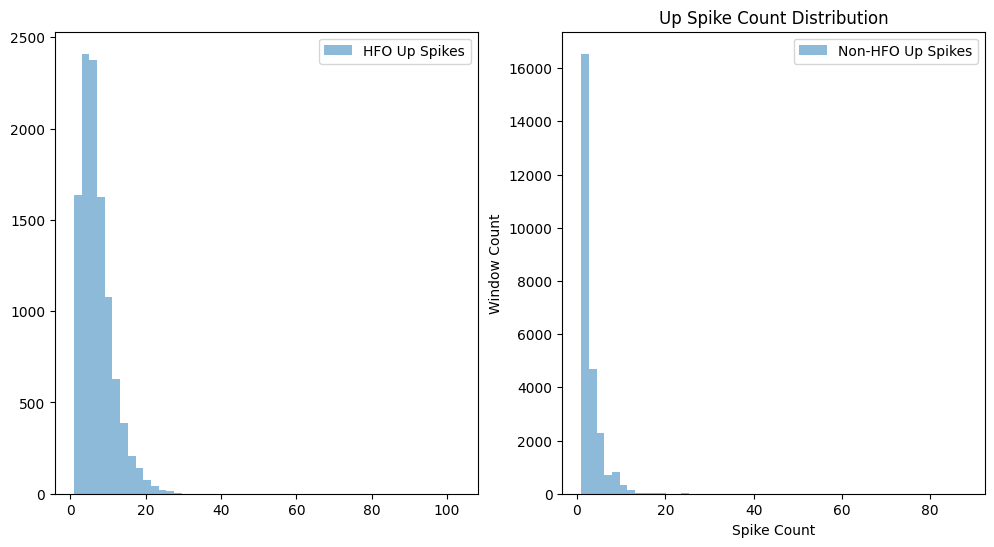

In [30]:
plt.subplots(1,2, figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(total_hfo_counts,bins=50, alpha=0.5, label='HFO Up Spikes')
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(total_nonhfo_counts, bins=50, alpha=0.5, label='Non-HFO Up Spikes')
plt.legend()
plt.title('Up Spike Count Distribution')
plt.xlabel('Spike Count')
plt.ylabel('Window Count')
plt.show()

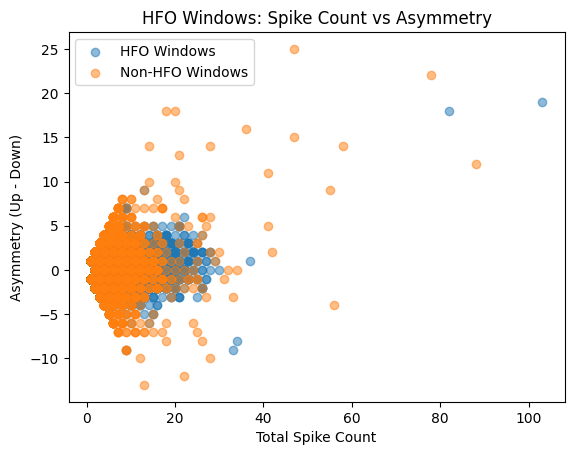

In [31]:
# Evaluate HFO windows
asymmetry_hfos = (hfo_up_counts - hfo_down_counts)
asymmetry_nonhfos = nonhfo_up_counts - nonhfo_down_counts

plt.scatter(total_hfo_counts,asymmetry_hfos , alpha=0.5, label='HFO Windows')
plt.scatter(total_nonhfo_counts,asymmetry_nonhfos, alpha=0.5, label='Non-HFO Windows')
plt.xlabel('Total Spike Count')
plt.ylabel('Asymmetry (Up - Down)')
plt.title('HFO Windows: Spike Count vs Asymmetry')
plt.legend()
plt.show()

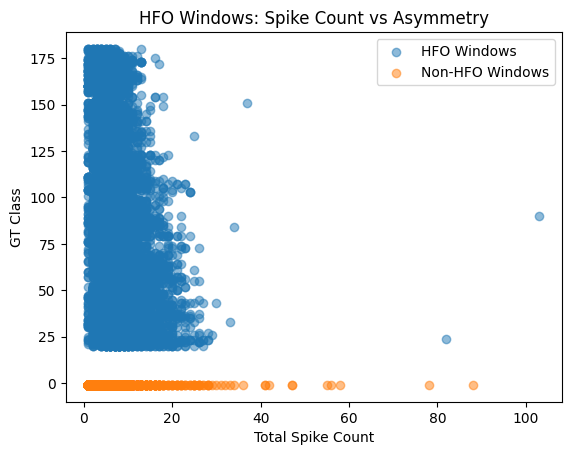

In [32]:
plt.scatter(total_hfo_counts,windowed_gt_hfo, alpha=0.5, label='HFO Windows')
plt.scatter(total_nonhfo_counts,windowed_gt_non_hfo, alpha=0.5, label='Non-HFO Windows')
plt.xlabel('Total Spike Count')
plt.ylabel('GT Class')
plt.title('HFO Windows: Spike Count vs Asymmetry')
plt.legend()

## Process - Remove Windows above thresholds

In [34]:
# print(average_total_hfo_counts)
# thresholds=[average_total_counts,average_total_hfo_counts*20]


nonhfo_threshold = np.percentile(og_total_nonhfo_counts, 90) 
hfo_activity_threshold = np.percentile(og_total_hfo_counts, 50) 
thresholds = [nonhfo_threshold, hfo_activity_threshold]

# thresholds=[100,50]
# p2_windowed_input_data,p2_windowed_gt,p2_ripple_ids=min_max_spike_threshold(p1_windowed_input_data,p1_windowed_gt,
#                                                                          p1_ripple_ids,MEAN_DETECTION_OFFSET,thresholds)

p2_windowed_input_data,p2_windowed_gt,p2_ripple_ids=min_max_spike_threshold_prob(windowed_input_data,windowed_gt,
                                                                         ripple_ids,thresholds,max_prob=0.9,multiplier=2,decay=3,drop_fn=drop_exponential)

False Positive Removed (Prob 0.78) - Spikes: 2.0
False Positive Removed (Prob 0.78) - Spikes: 2.0
False Positive Removed (Prob 0.78) - Spikes: 2.0
False Positive Removed (Prob 0.70) - Spikes: 3.0
False Positive Removed (Prob 0.83) - Spikes: 1.0
False Positive Removed (Prob 0.78) - Spikes: 2.0
False Positive Removed (Prob 0.78) - Spikes: 2.0
False Positive Removed (Prob 0.57) - Spikes: 4.0
False Negative Removed (Prob 0.35) - Spikes: 7.0
False Negative Removed (Prob 0.57) - Spikes: 8.0
False Positive Removed (Prob 0.57) - Spikes: 4.0
False Negative Removed (Prob 0.35) - Spikes: 7.0
False Positive Removed (Prob 0.57) - Spikes: 4.0
False Positive Removed (Prob 0.57) - Spikes: 4.0
False Positive Removed (Prob 0.78) - Spikes: 2.0
False Positive Removed (Prob 0.35) - Spikes: 5.0
False Negative Removed (Prob 0.57) - Spikes: 8.0
False Negative Removed (Prob 0.57) - Spikes: 8.0
False Negative Removed (Prob 0.35) - Spikes: 7.0
False Negative Removed (Prob 0.35) - Spikes: 7.0
False Negative Remov

In [35]:
# See GT Class Distribution
# Set print options to see more elements
np.set_printoptions(linewidth=100, threshold=50, edgeitems=20)
print(f"Ground Truth Class Distribution: {np.unique(p2_windowed_gt, return_counts=True)}")



GT_HFO_MASK = p2_windowed_gt >= 0
# print(windowed_gt[0:1000])
# Define the number of windows with an HFO
num_hfo_windows = np.sum(GT_HFO_MASK)
print(f"Number of windows with an HFO: {num_hfo_windows}")
print(f"Percentage of windows with an HFO: {num_hfo_windows / p2_windowed_gt.shape[0] * 100:.2f}%")

Ground Truth Class Distribution: (array([ -1.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38., ..., 161., 162., 163., 164., 165., 166., 167., 168., 169.,
       170., 171., 172., 173., 174., 175., 176., 177., 178., 179., 180.], dtype=float32), array([24392,   123,    64,   146,   182,    82,    73,   118,    99,    69,    48,    71,    89,
         160,   128,    34,    95,   127,   137,    17, ...,    13,    11,    26,    42,    45,
          28,    19,    34,     2,    40,    18,    16,    15,    27,    12,    23,    19,    28,
          14,    18], dtype=int64))
Number of windows with an HFO: 8246
Percentage of windows with an HFO: 25.27%


In [36]:
# Find the indices to sort the input data by the nº of UP/DN spikes (descending order)
sorted_indices = np.argsort(
    -(np.sum(p2_windowed_input_data[:, :, 0], axis=1) + np.sum(p2_windowed_input_data[:, :, 1], axis=1)), 
)
sorted_spikes = p2_windowed_input_data[sorted_indices]
sorted_gt= p2_windowed_gt[sorted_indices]
sorted_ripples=p2_ripple_ids[sorted_indices]
sorted_up_spikes_per_window = np.sum(sorted_spikes[:, :, 0], axis=1)    # Sum along time axis
sorted_down_spikes_per_window = np.sum(sorted_spikes[:, :, 1], axis=1)  # Sum along time axis
print(f"sorted_indices: {sorted_indices}")
print(f"Sorted_data: {sorted_spikes.shape} | Sorted_gt: {sorted_gt.shape}")
print(f"Sorted_gt preview: {sorted_gt[:10]}")
print(f"GT first window: {sorted_gt[0]} | GT last window: {sorted_gt[-1]}")

sorted_indices: [13945 13946 13947 13938 13933 11761 13967 29059 29063 27517 27713 29146 27755 27775 28619 30754
 27553 29021 28614 32173 ... 16380 16381 16385 16386 16387 16460 16388 16392 16394 16400 16403
 16415 16418 16424 16430 16437 16446 16451 16389 32637]
Sorted_data: (32638, 200, 2) | Sorted_gt: (32638,)
Sorted_gt preview: [ 90.  24.  -1. 151.  84.  33.  -1.  43.  26.  23.]
GT first window: 90.0 | GT last window: -1.0


In [37]:
sorted_gt_distribution=sorted_gt[:1000]
sorted_ripple_distribution=sorted_ripples[:1000]

print(f"Sorted GT Distribution: {np.unique(sorted_gt_distribution, return_counts=True)}")
print(f"Sorted Ripple Distribution: {np.unique(sorted_ripple_distribution, return_counts=True)}")


Sorted GT Distribution: (array([ -1.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  39., ..., 113., 114., 117., 118., 119., 120., 122., 123., 130.,
       133., 136., 141., 145., 147., 149., 151., 154., 172., 173., 175.], dtype=float32), array([21, 27, 27, 23, 45, 22, 16, 28, 33,  6,  4, 19,  7, 15, 28,  2, 19, 32, 39,  1, ...,  2,  2,
        2,  2,  2,  5,  1,  7,  2,  3,  3,  3,  1,  1,  2,  1,  3,  1,  2,  1], dtype=int64))
Sorted Ripple Distribution: (array([  -1,    0,   27,   38,   41,   90,   93,  105,  110,  113,  122,  126,  138,  140,  150,
        193,  194,  199,  205,  207, ..., 2068, 2072, 2075, 2084, 2092, 2095, 2096, 2097, 2098,
       2099, 2106, 2110, 2111, 2113, 2119, 2123, 2142, 2150, 2155, 2158]), array([21,  6,  2,  1,  1,  2,  1,  2,  1,  8,  8,  8,  8,  5,  1,  1,  3,  1,  1,  2, ...,  5,  2,
        3,  5,  4,  1,  1,  1,  5,  5,  2,  5,  5,  3,  2,  1,  4,  2,  3,  1], dtype=int64))


In [38]:
is_hfo = p2_windowed_gt >= 0
hfo_windows = p2_windowed_input_data[is_hfo]       # shape: (N_HFO, 180, 2)
non_hfo_windows = p2_windowed_input_data[~is_hfo]  # shape: (N_nonHFO, 180, 2)
windowed_gt_hfo = p2_windowed_gt[is_hfo]       # shape: (N_HFO, 180, 2)
windowed_gt_non_hfo = p2_windowed_gt[~is_hfo]  # shape: (N_nonHFO, 180, 2)

In [39]:
# Sum over time axis
hfo_up_counts = np.sum(hfo_windows[:, :, 0], axis=1)
hfo_down_counts = np.sum(hfo_windows[:, :, 1], axis=1)
total_hfo_counts= hfo_up_counts + hfo_down_counts
nonhfo_up_counts = np.sum(non_hfo_windows[:, :, 0], axis=1)
nonhfo_down_counts= np.sum(non_hfo_windows[:, :,1], axis=1)
total_nonhfo_counts = nonhfo_up_counts + nonhfo_down_counts

average_hfo_up_counts = np.mean(hfo_up_counts)
average_hfo_down_counts = np.mean(hfo_down_counts)
average_total_hfo_counts = np.mean(total_hfo_counts)
average_nonhfo_up_counts = np.mean(nonhfo_up_counts)
average_nonhfo_down_counts = np.mean(nonhfo_down_counts)
average_total_nonhfo_counts = np.mean(total_nonhfo_counts)
average_total_counts= (np.sum(total_hfo_counts)+np.sum(total_nonhfo_counts))/len(p2_windowed_input_data)
print(f"Average HFO Up Counts: {average_hfo_up_counts}")
print(f"Average HFO Down Counts: {average_hfo_down_counts}")
print(f"Average Total HFO Counts: {average_total_hfo_counts}")
print(f"Average Non-HFO Up Counts: {average_nonhfo_up_counts}")
print(f"Average Non-HFO Down Counts: {average_nonhfo_down_counts}")
print(f"Average Total Non-HFO Counts: {average_total_nonhfo_counts}")
print(f"Average Total Counts: {average_total_counts}")
print(f"Number of windows with an HFO: {num_hfo_windows}")
print(f"Number of windows without an HFO:", len(p2_windowed_input_data)-num_hfo_windows)

Average HFO Up Counts: 4.316638370118845
Average HFO Down Counts: 4.178995876788746
Average Total HFO Counts: 8.495634246907592
Average Non-HFO Up Counts: 1.2666038045260741
Average Non-HFO Down Counts: 1.1915382092489342
Average Total Non-HFO Counts: 2.4581420137750083
Average Total Counts: 3.983516146822722
Number of windows with an HFO: 8246
Number of windows without an HFO: 24392


In [40]:
# Example for all HFO windows (up channel):
hfo_up_isis = [get_isi(window[:, :]) for window in hfo_windows]
nonhfo_up_isis = [get_isi(window[:, :]) for window in non_hfo_windows]

hfo_up_isi_mean = np.array([np.mean(isi) if len(isi) > 0 else 0 for isi in hfo_up_isis])
nonhfo_up_isi_mean = np.array([np.mean(isi) if len(isi) > 0 else 0 for isi in nonhfo_up_isis])

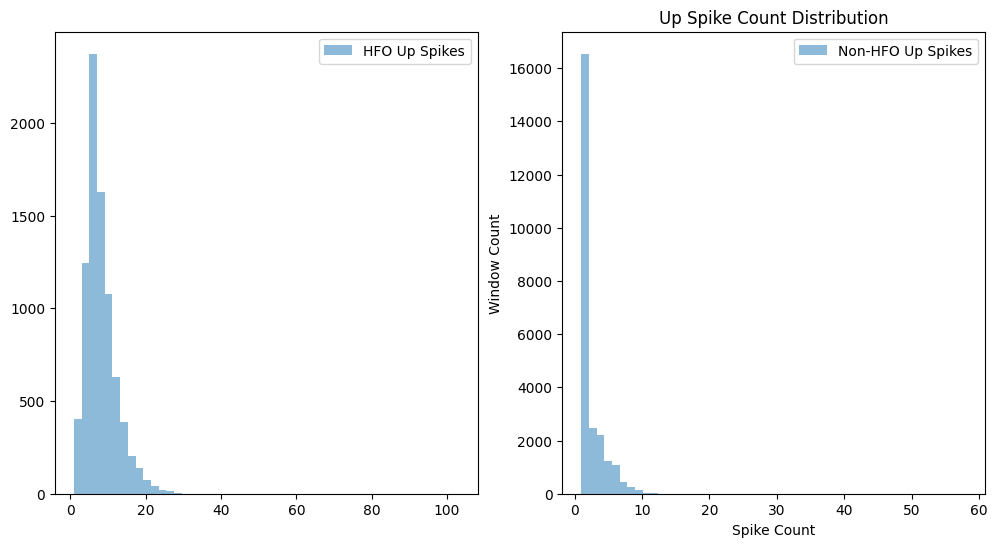

In [41]:
plt.subplots(1,2, figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(total_hfo_counts,bins=50, alpha=0.5, label='HFO Up Spikes')
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(total_nonhfo_counts, bins=50, alpha=0.5, label='Non-HFO Up Spikes')
plt.legend()
plt.title('Up Spike Count Distribution')
plt.xlabel('Spike Count')
plt.ylabel('Window Count')
plt.show()

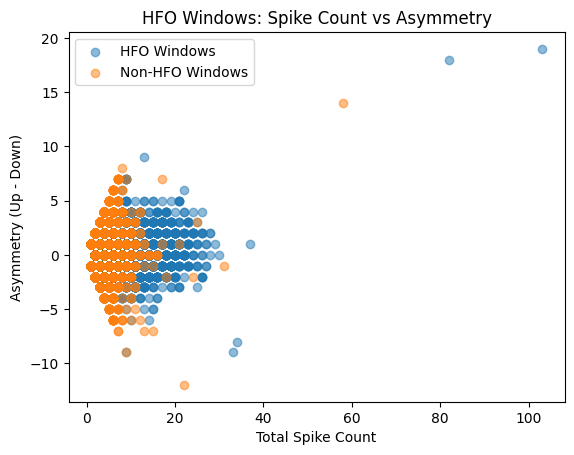

In [42]:
# Evaluate HFO windows
asymmetry_hfos = (hfo_up_counts - hfo_down_counts)
asymmetry_nonhfos = nonhfo_up_counts - nonhfo_down_counts

plt.scatter(total_hfo_counts,asymmetry_hfos , alpha=0.5, label='HFO Windows')
plt.scatter(total_nonhfo_counts,asymmetry_nonhfos, alpha=0.5, label='Non-HFO Windows')
plt.xlabel('Total Spike Count')
plt.ylabel('Asymmetry (Up - Down)')
plt.title('HFO Windows: Spike Count vs Asymmetry')
plt.legend()
plt.show()

Text(0.5, 1.0, 'HFO Windows: Spike Count vs Asymmetry')

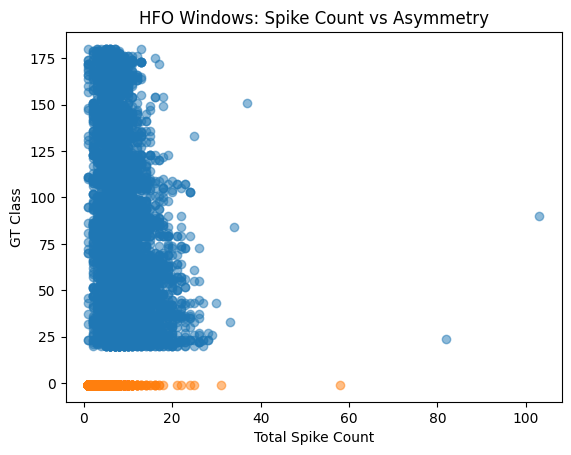

In [43]:
plt.scatter(total_hfo_counts,windowed_gt_hfo, alpha=0.5, label='HFO Windows')
plt.scatter(total_nonhfo_counts,windowed_gt_non_hfo, alpha=0.5, label='Non-HFO Windows')
plt.xlabel('Total Spike Count')
plt.ylabel('GT Class')
plt.title('HFO Windows: Spike Count vs Asymmetry')

## After Undersampling Non-Ripples

In [44]:
from snnTorch.utils.training import undersample_majority, oversample_minority
intermediate_input, intermediate_gt = windowed_input_data, windowed_gt  # Default: No Balancing
balance=True
if balance:
    intermediate_input, intermediate_gt = undersample_majority(windowed_input_data, windowed_gt)
    # intermediate_input, intermediate_gt = undersample_majority(p2_windowed_input_data, p2_windowed_gt)  

# Print the number of samples in each class
print(f"Intermediate GT Class Distribution: {np.unique(intermediate_gt, return_counts=True)}")
print(f"Intermediate Window Input Data Shape: {intermediate_input.shape}")


Intermediate GT Class Distribution: (array([ -1.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38., ..., 161., 162., 163., 164., 165., 166., 167., 168., 169.,
       170., 171., 172., 173., 174., 175., 176., 177., 178., 179., 180.], dtype=float32), array([10648,   134,    78,   171,   209,    89,    88,   141,   112,    79,    55,    82,   103,
         194,   141,    52,   108,   150,   150,    21, ...,    22,    23,    38,    68,    74,
          52,    37,    81,     7,    53,    28,    28,    15,    55,    15,    31,    38,    53,
          30,    37], dtype=int64))
Intermediate Window Input Data Shape: (21296, 200, 2)


In [45]:
is_hfo= intermediate_gt >= 0
hfo_windows = intermediate_input[is_hfo]       # shape: (N_HFO, 180, 2)
non_hfo_windows = intermediate_input[~is_hfo]  # shape: (N_nonHFO, 180, 2)
windowed_gt_hfo = intermediate_gt[is_hfo]       # shape: (N_HFO, 180, 2)
windowed_gt_non_hfo = intermediate_gt[~is_hfo]  # shape: (N_nonHFO, 180, 2)
print(f"Number of HFO windows: {hfo_windows.shape[0]}")
print(f"Number of Non-HFO windows: {non_hfo_windows.shape[0]}")

Number of HFO windows: 10648
Number of Non-HFO windows: 10648


In [ ]:
# Sum over time axis
hfo_up_counts = np.sum(hfo_windows[:, :, 0], axis=1)
hfo_down_counts = np.sum(hfo_windows[:, :, 1], axis=1)
total_hfo_counts= hfo_up_counts + hfo_down_counts
nonhfo_up_counts = np.sum(non_hfo_windows[:, :, 0], axis=1)
nonhfo_down_counts= np.sum(non_hfo_windows[:, :,1], axis=1)
total_nonhfo_counts = nonhfo_up_counts + nonhfo_down_counts

average_hfo_up_counts = np.mean(hfo_up_counts)
average_hfo_down_counts = np.mean(hfo_down_counts)
average_total_hfo_counts = np.mean(total_hfo_counts)
average_nonhfo_up_counts = np.mean(nonhfo_up_counts)
average_nonhfo_down_counts = np.mean(nonhfo_down_counts)
average_total_nonhfo_counts = np.mean(total_nonhfo_counts)
average_total_counts= (np.sum(total_hfo_counts)+np.sum(total_nonhfo_counts))/len(intermediate_input)

print(f"Average HFO Up Counts: {average_hfo_up_counts}")
print(f"Average HFO Down Counts: {average_hfo_down_counts}")
print(f"Average Total HFO Counts: {average_total_hfo_counts}")
print(f"Average Non-HFO Up Counts: {average_nonhfo_up_counts}")
print(f"Average Non-HFO Down Counts: {average_nonhfo_down_counts}")
print(f"Average Total Non-HFO Counts: {average_total_nonhfo_counts}")
print(f"Average Total Counts: {average_total_counts}")

# Example for all HFO windows (up channel):
hfo_up_isis = [get_isi(window[:, :]) for window in hfo_windows]
nonhfo_up_isis = [get_isi(window[:, :]) for window in non_hfo_windows]

hfo_up_isi_mean = np.array([np.mean(isi) if len(isi) > 0 else 0 for isi in hfo_up_isis])
nonhfo_up_isi_mean = np.array([np.mean(isi) if len(isi) > 0 else 0 for isi in nonhfo_up_isis])


In [ ]:
plt.subplots(1,2, figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(total_hfo_counts,bins=50, alpha=0.5, label='HFO Up Spikes')
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(total_nonhfo_counts, bins=50, alpha=0.5, label='Non-HFO Up Spikes')
plt.legend()
plt.title('Up Spike Count Distribution')
plt.xlabel('Spike Count')
plt.ylabel('Window Count')
plt.show()

In [ ]:
plt.subplots(1,2, figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(hfo_up_isi_mean, bins=50, alpha=0.5, label='HFO ISI (Up)')
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(nonhfo_up_isi_mean, bins=50, alpha=0.5, label='Non-HFO ISI (Up)')
plt.legend()
plt.suptitle('Mean Inter-Spike Interval per Window')
plt.xlabel('ISI')
plt.ylabel('Window Count')
plt.show()

In [ ]:
plt.subplots(figsize=(12, 6))
plt.hist(windowed_gt_hfo, bins=50, alpha=0.5, label='HFO GT')
plt.legend()
plt.title('Distribution of HFO GT Classes')
plt.xlabel('Ground Truth Class')
plt.ylabel('Window Count')
plt.show()

In [ ]:
# Evaluate HFO windows
asymmetry_hfos = (hfo_up_counts - hfo_down_counts)
asymmetry_nonhfos = nonhfo_up_counts - nonhfo_down_counts

plt.scatter(total_hfo_counts,asymmetry_hfos , alpha=0.2, label='HFO Windows')
plt.scatter(total_nonhfo_counts,asymmetry_nonhfos, alpha=0.2, label='Non-HFO Windows')
plt.xlabel('Total Spike Count')
plt.ylabel('Asymmetry (Up - Down)')
plt.title('HFO Windows: Spike Count vs Asymmetry')
plt.legend()
plt.show()

In [ ]:
plt.scatter(total_hfo_counts,windowed_gt_hfo, alpha=0.5, label='HFO Windows')
plt.scatter(total_nonhfo_counts,windowed_gt_non_hfo, alpha=0.5, label='Non-HFO Windows')
plt.xlabel('Total Spike Count')
plt.ylabel('GT Class')
plt.title('HFO Windows: Spike Count vs GT Class')

In [22]:
def make_serializable(obj):
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()  # Convert to native Python int or float
    elif isinstance(obj, np.ndarray):
        return obj.tolist()  # Convert arrays to lists
    elif isinstance(obj, dict):
        return {k: make_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [make_serializable(v) for v in obj]
    else:
        return obj

In [19]:
# Save the windowed 
# input data and ground truth to a file
save=True
if save:
    windowed_save=os.path.join(curr_dir,"windowed_data")
    os.makedirs(windowed_save, exist_ok=True)
    np.save(os.path.join(windowed_save, "filtered_windows.npy"), filtered_windows, allow_pickle=True)
    np.save(os.path.join(windowed_save, "windowed_input_data.npy"), windowed_input_data, allow_pickle=True)
    np.save(os.path.join(windowed_save,"windowed_gt.npy"), windowed_gt, allow_pickle=True)
    np.save(os.path.join(windowed_save,"ripple_ids.npy"), ripple_ids, allow_pickle=True)
    
    # Save the configuration to a JSON file
    with open(os.path.join(windowed_save, "config.json"), 'w') as f:
        serializable_config = make_serializable(config)
        json.dump(serializable_config, f, indent=4)

NameError: name 'make_serializable' is not defined